In [78]:
%matplotlib widget
import matplotlib.pyplot as plt
import hyperspy.api as hs
import numpy as np
import h5py as h5
import glob
import json

In [2]:
fp = r'/dls/e02/data/2026/mg42732-1/processing/Merlin/2ML/20260227_111631/20260227_111631_data_bin_nav_factor_2.hspy'

In [3]:
d = hs.load(fp, reader = 'HSPY')# lazy = True)

In [49]:
#set calibration
#currently it has no units!
d.axes_manager

Navigation axis name,size,index,offset,scale,units
,127,69,0.0,1.0,
,127,46,0.0,1.0,
Signal axis name,size,,offset,scale,units
,515,,0.0,1.0,
,515,,0.0,1.0,


In [65]:
#check meta_data#
meta_data = {}
meta_file = fp.split('_data')[0] +'.hdf'
print(meta_file)
with h5.File(meta_file) as f:
    for this_key in f['metadata'].keys():
        try:
            meta_data.update({this_key:f['metadata'][this_key][()]})
            print('loaded: ' , this_key)
        except:
            continue
        #d.update({"c": 3})

/dls/e02/data/2026/mg42732-1/processing/Merlin/2ML/20260227_111631/20260227_111631.hdf
loaded:  A1_value_(kV)
loaded:  A2_value_(kV)
loaded:  aperture_size
loaded:  convergence_semi-angle(rad)
loaded:  current_OLfine
loaded:  defocus(nm)
loaded:  defocus_per_bit(nm)
loaded:  field_of_view(m)
loaded:  ht_value(V)
loaded:  magnification
loaded:  merlin_camera_length(m)
loaded:  nominal_camera_length(m)
loaded:  nominal_scan_rotation
loaded:  set_bit_depth
loaded:  set_dwell_time(usec)
loaded:  set_scan_px
loaded:  spot_size
loaded:  step_size(m)
loaded:  x_pos(m)
loaded:  x_tilt(deg)
loaded:  y_pos(m)
loaded:  y_tilt(deg)
loaded:  z_pos(m)
loaded:  zero_OLfine


In [69]:
#show camera_length 
print('CL : ' , meta_data['nominal_camera_length(m)'])
#and field of view
print('FOV : ' , meta_data['field_of_view(m)'])

CL :  0.4
FOV :  8.000000000000001e-07


In [77]:
#now we need to get the calibrated reciprocal px size from the Au calibration!!
Au_calibration_folder = fp.split('Merlin/')[0] + 'Merlin/au_xgrating'
print(Au_calibration_folder)
Au_cal_files = glob.glob(Au_calibration_folder + '/**/*.json', recursive = True)
for i, this_cal_file in enumerate(Au_cal_files):
    print(i, this_cal_file)

/dls/e02/data/2026/mg42732-1/processing/Merlin/au_xgrating
0 /dls/e02/data/2026/mg42732-1/processing/Merlin/au_xgrating/20260225_094521/20260225_094521_CL_20cm.json
1 /dls/e02/data/2026/mg42732-1/processing/Merlin/au_xgrating/20260225_094001/20260225_094001_CL_20cm.json
2 /dls/e02/data/2026/mg42732-1/processing/Merlin/au_xgrating/20260225_094752/20260225_094752_CL_40cm.json
3 /dls/e02/data/2026/mg42732-1/processing/Merlin/au_xgrating/20260225_094207/20260225_094207_CL_20cm.json


In [82]:
#choose your cal file for the correct camera length!!!
n = 2
with open(Au_cal_files[n]) as f:
    this_cal = json.load(f)
    print(this_cal)


{'reciprocal_space_pix(1/A)': 0.00559644685621419, 'p_ellipse': [291.1711119545025, 298.8427732532748, 128.62181726480085, 124.00660740326857, -2.9094849250916544], 'nominal_camera_length(m)': 0.4}


In [83]:
#add these to meta_data
meta_data.update(this_cal)

In [84]:
meta_data

{'A1_value_(kV)': 4.159999847412109,
 'A2_value_(kV)': 5.179999828338623,
 'aperture_size': 4,
 'convergence_semi-angle(rad)': 0.0,
 'current_OLfine': 39050,
 'defocus(nm)': 0.0,
 'defocus_per_bit(nm)': 0.75,
 'field_of_view(m)': 8.000000000000001e-07,
 'ht_value(V)': 300000.0,
 'magnification': 250000,
 'merlin_camera_length(m)': 0.4,
 'nominal_camera_length(m)': 0.4,
 'nominal_scan_rotation': 0,
 'set_bit_depth': 6,
 'set_dwell_time(usec)': 1000,
 'set_scan_px': 256,
 'spot_size': 6,
 'step_size(m)': 3.1250000000000003e-09,
 'x_pos(m)': 1.3325500000000001e-05,
 'x_tilt(deg)': 0.0,
 'y_pos(m)': -1.0654099609375e-05,
 'y_tilt(deg)': 0.0,
 'z_pos(m)': -0.00013193590625,
 'zero_OLfine': 39050,
 'reciprocal_space_pix(1/A)': 0.00559644685621419,
 'p_ellipse': [291.1711119545025,
  298.8427732532748,
  128.62181726480085,
  124.00660740326857,
  -2.9094849250916544]}

In [116]:
#add calibrations to data - IGNORE THE ERRORS HERE!!!
d.axes_manager[0].scale = meta_data['field_of_view(m)'] / d.data.shape[0]
d.axes_manager[1].scale = meta_data['field_of_view(m)'] / d.data.shape[0]

d.axes_manager[0].units = 'm'
d.axes_manager[1].units = 'm'

d.axes_manager[2].scale = meta_data['reciprocal_space_pix(1/A)'] 
d.axes_manager[3].scale = meta_data['reciprocal_space_pix(1/A)'] 

d.axes_manager[2].units = 'A^{-1}'
d.axes_manager[3].units = 'A^{-1}'

In [90]:
d.axes_manager

Navigation axis name,size,index,offset,scale,units
,127,69,0.0,6.299212598425198e-09,m
,127,46,0.0,6.299212598425198e-09,m
Signal axis name,size,,offset,scale,units
,515,,0.0,0.00559644685621419,A^{-1}
,515,,0.0,0.00559644685621419,A^{-1}


In [91]:
#interactive display
d.plot(norm = 'symlog')

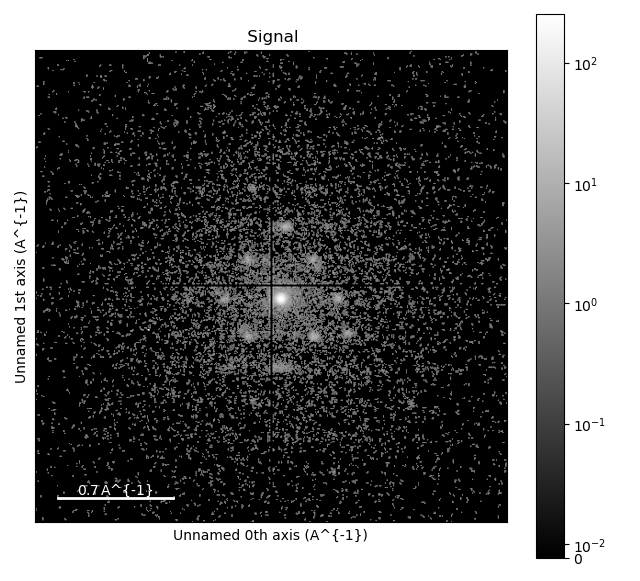

In [92]:
#show one diffraction pattern
d.inav[69,46].plot(norm = 'symlog')

In [7]:
#take sum diff pattern
d_sum = d.sum()

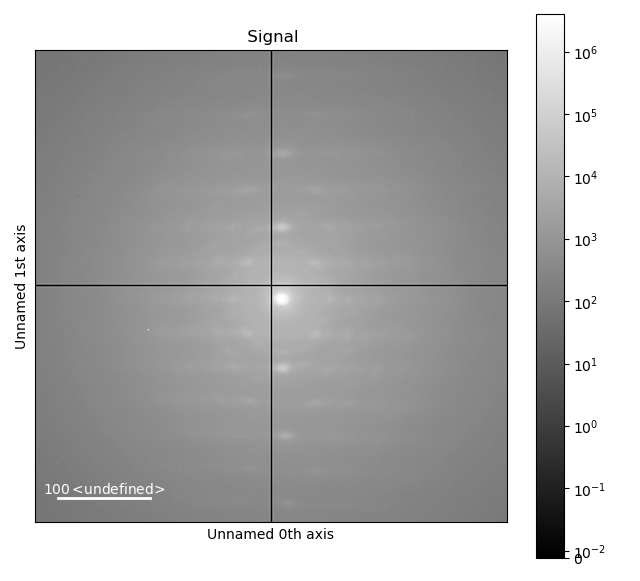

In [9]:
#and plot
d_sum.plot(norm = 'symlog')

In [11]:
#make incoherent BF image
bf = d.sum(axis = [2,3])

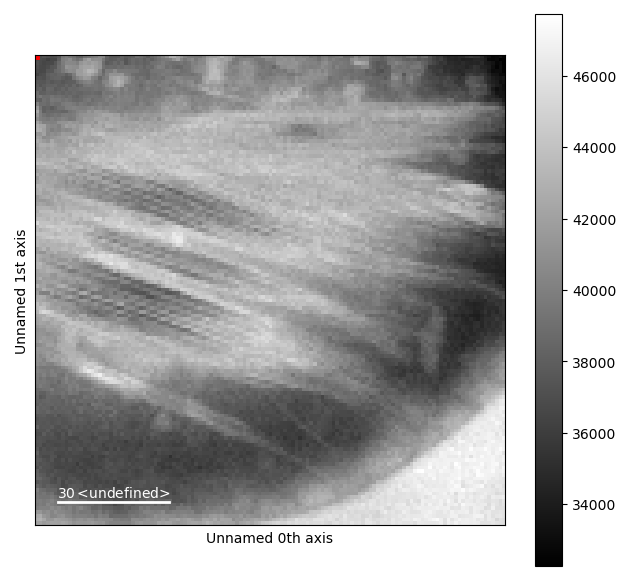

In [25]:
#and show
bf.plot()

In [15]:
#make a region of interest
d.plot()
rect = hs.roi.RectangularROI()
this_rect = rect.interactive(d)

In [17]:
#show details of region of interest
this_rect

<ElectronDiffraction2D, title: , dimensions: (47, 42|515, 515)>

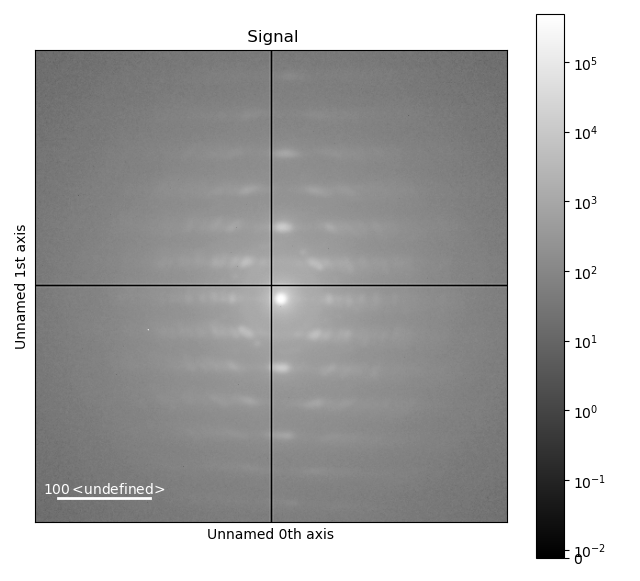

In [19]:
#plot all diffraction patterns in ROI
this_rect.sum().plot(norm = 'symlog')

/tmp/ipykernel_165/1930452965.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.matshow(a_mask)


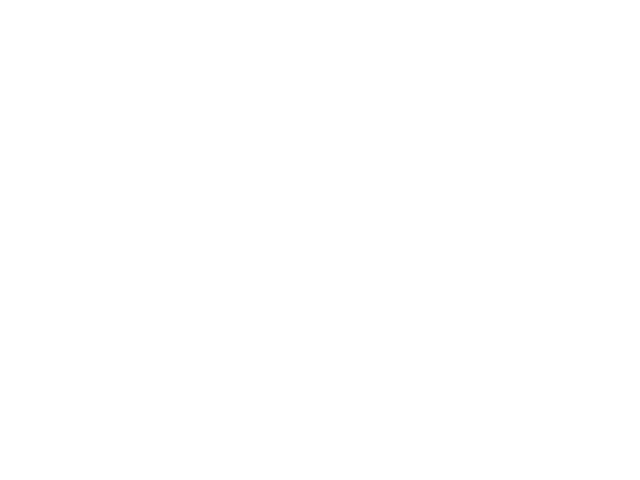

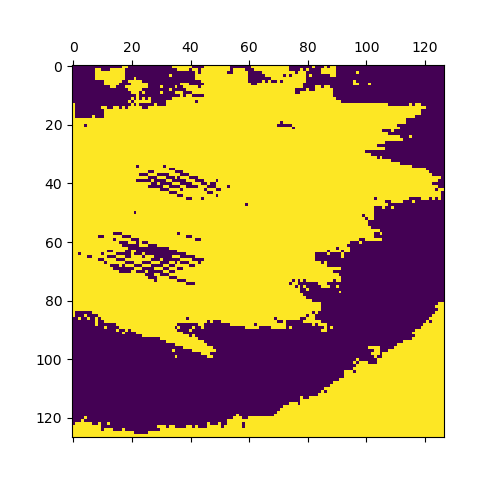

In [93]:
#create a mask
a_mask = np.zeros_like(d.data[:,:,0,0])
a_mask[bf> 4e4]= 1
plt.figure()
plt.matshow(a_mask)

In [94]:
#mask the data
hs_mask =hs.signals.Signal2D(data = a_mask)

In [95]:
masked_data = d.deepcopy()
masked_data = masked_data *hs_mask.T

WARNING | Hyperspy | Axis calibration mismatch detected along axis 0. The calibration of signal 0 along this axis will be applied to all signals after stacking. (hyperspy.misc.signal_tools:109)


WARNING | Hyperspy | Axis calibration mismatch detected along axis 1. The calibration of signal 0 along this axis will be applied to all signals after stacking. (hyperspy.misc.signal_tools:109)


In [96]:
masked_data.plot()

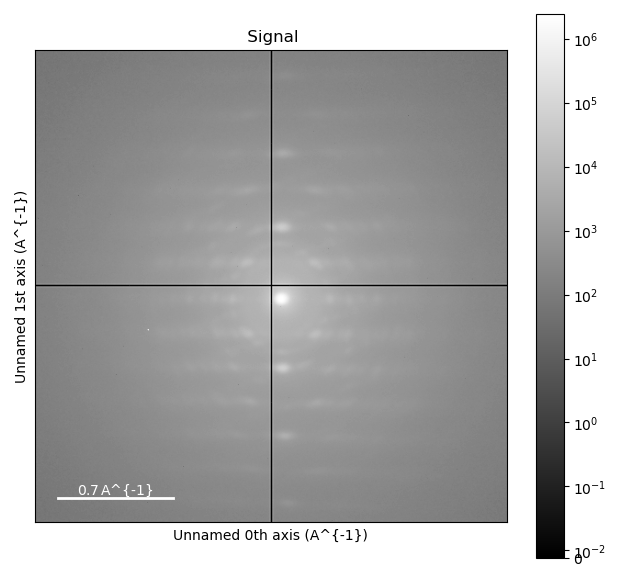

In [99]:
#'sum masked data
masked_sum = masked_data.sum()
masked_sum.plot(norm= 'symlog')

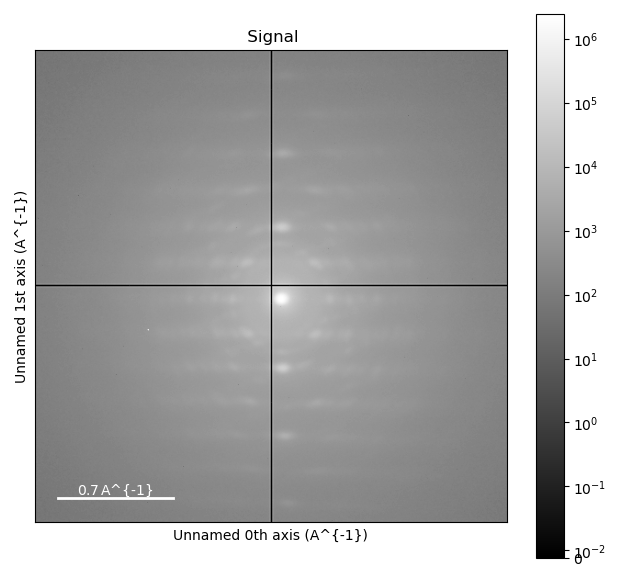

In [100]:
line_roi = hs.roi.Line2DROI(linewidth = 10)
masked_sum.plot(norm = 'symlog')
this_line = line_roi.interactive(masked_sum)

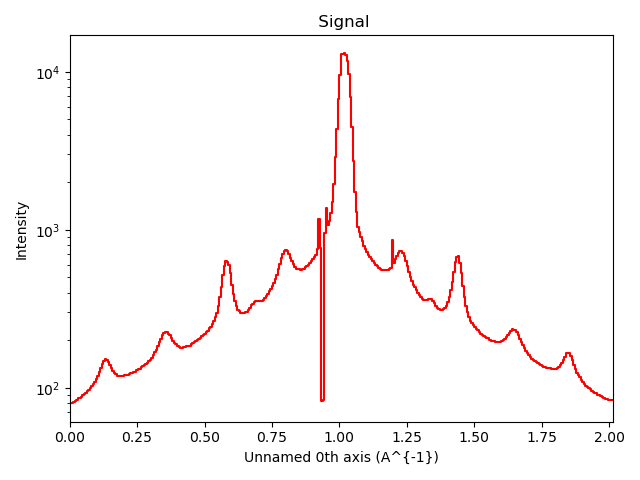

In [101]:
a_span = hs.roi.SpanROI()#left = 10 , right = 100)
this_line.plot(norm = 'log')
this_span = a_span.interactive(this_line)

In [117]:
# get span distance:
span_dist = this_span.axes_manager[0].scale * this_span.data.shape[0]
print('span distance = ', span_dist, 'Ang^{-1}')

span distance =  0.8571339108995683 Ang^{-1}
